<a href="https://colab.research.google.com/github/Sreenithabhuvanapalli28/Machine-Learning-Lab/blob/main/linear_vs_polynomial_regression_exp_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Performance Metrics ---
Linear Model (Degree 1):  MSE = 3.02, R2 Score = 0.43
Polynomial Model (Degree 2): MSE = 0.78, R2 Score = 0.85


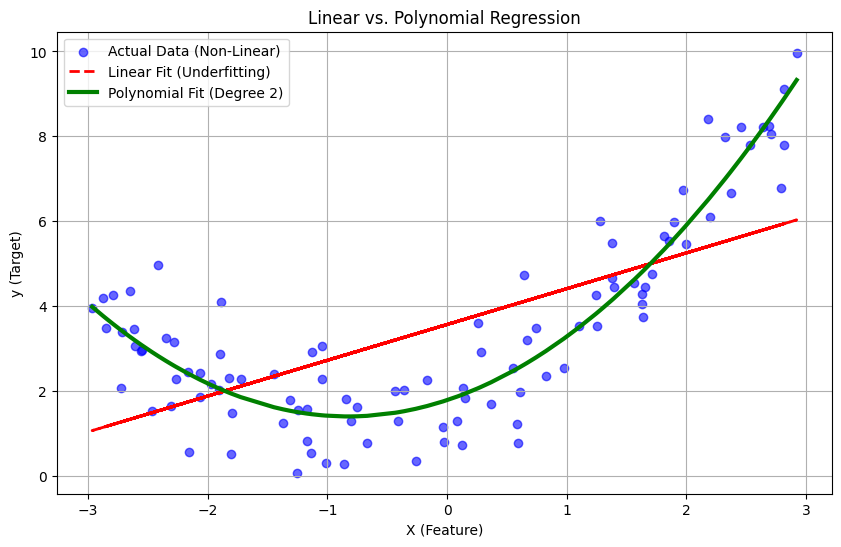

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# 1. Generate Synthetic Non-Linear Data
# We create a quadratic relationship: y = 0.5x^2 + x + 2 + noise
np.random.seed(42)
X = 6 * np.random.rand(100, 1) - 3  # X values between -3 and 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1) # Quadratic equation with noise

# 2. Linear Regression (Degree 1)
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_lin = lin_reg.predict(X)

# 3. Polynomial Regression (Degree 2)
# Transform X into polynomial features (X, X^2)
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_pred_poly = poly_reg.predict(X_poly)

# 4. Evaluation Metrics
mse_lin = mean_squared_error(y, y_pred_lin)
r2_lin = r2_score(y, y_pred_lin)

mse_poly = mean_squared_error(y, y_pred_poly)
r2_poly = r2_score(y, y_pred_poly)

print(f"--- Performance Metrics ---")
print(f"Linear Model (Degree 1):  MSE = {mse_lin:.2f}, R2 Score = {r2_lin:.2f}")
print(f"Polynomial Model (Degree 2): MSE = {mse_poly:.2f}, R2 Score = {r2_poly:.2f}")

# 5. Visualization
plt.figure(figsize=(10, 6))

# Plot original data
plt.scatter(X, y, color='blue', alpha=0.6, label='Actual Data (Non-Linear)')

# Plot Linear Regression Line
plt.plot(X, y_pred_lin, color='red', linewidth=2, linestyle='--', label='Linear Fit (Underfitting)')

# Plot Polynomial Regression Curve
# Note: To plot a smooth curve, we need to sort X values
X_sorted = np.sort(X, axis=0)
X_sorted_poly = poly_features.transform(X_sorted)
y_curve = poly_reg.predict(X_sorted_poly)
plt.plot(X_sorted, y_curve, color='green', linewidth=3, label='Polynomial Fit (Degree 2)')

plt.title('Linear vs. Polynomial Regression')
plt.xlabel('X (Feature)')
plt.ylabel('y (Target)')
plt.legend()
plt.grid(True)
plt.show()